# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
dataset = pd.read_csv('./dataset/apbd_data_2026.csv')
dataset.head()

,Tahun,Periode,Provinsi,Pemda,Akun,Anggaran,Realisasi,Persentase
0,2026,4,Provinsi Aceh,Kab. Pidie,Pendapatan Daerah,2.130753e+12,3.959383e+11,18.58
1,2026,4,Provinsi Aceh,Kab. Pidie,PAD,2.773863e+11,1.341746e+10,4.84
2,2026,4,Provinsi Aceh,Kab. Pidie,Pajak Daerah,4.019619e+10,1.078136e+10,26.82
3,2026,4,Provinsi Aceh,Kab. Pidie,Retribusi Daerah,2.261942e+11,1.199382e+09,0.53
4,2026,4,Provinsi Aceh,Kab. Pidie,Hasil Pengelolaan Kekayaan Daerah yang Dipisahkan,3.000000e+09,0.000000e+00,0.00


In [5]:
dataset.info()
dataset.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 15291 entries, 0 to 15290
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tahun       15291 non-null  int64  
 1   Periode     15291 non-null  int64  
 2   Provinsi    15291 non-null  str    
 3   Pemda       15291 non-null  str    
 4   Akun        15291 non-null  str    
 5   Anggaran    15115 non-null  float64
 6   Realisasi   15291 non-null  float64
 7   Persentase  15291 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 955.8 KB


,Tahun,Periode,Provinsi,Pemda,Akun,Anggaran,Realisasi,Persentase
count,15291.0,15291.0,15291,15291,15291,1.511500e+04,1.529100e+04,15291
unique,NaN,NaN,38,544,37,NaN,NaN,3425
top,NaN,NaN,Provinsi Jawa Timur,Kab. Tanggamus,Belanja Pegawai,NaN,NaN,0.00
freq,NaN,NaN,1089,34,1088,NaN,NaN,4514
mean,2026.0,4.0,NaN,NaN,NaN,4.992702e+11,8.066604e+10,NaN
std,0.0,0.0,NaN,NaN,NaN,1.588222e+12,2.466427e+11,NaN
min,2026.0,4.0,NaN,NaN,NaN,-2.859854e+11,-7.328732e+09,NaN
25%,2026.0,4.0,NaN,NaN,NaN,1.508176e+10,0.000000e+00,NaN
50%,2026.0,4.0,NaN,NaN,NaN,1.098468e+11,3.347979e+09,NaN
75%,2026.0,4.0,NaN,NaN,NaN,5.295680e+11,7.302370e+10,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_7507/2025813625.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()


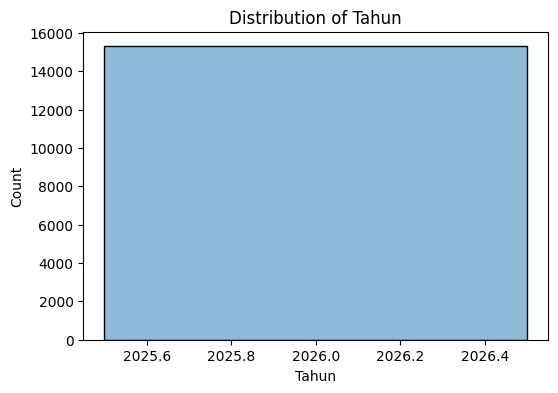

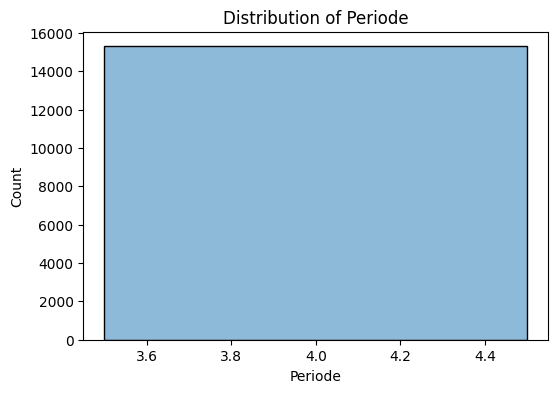

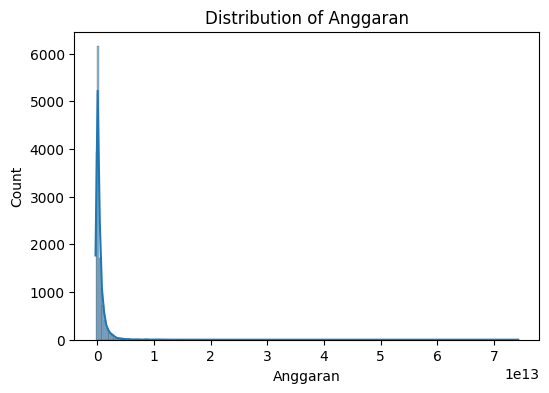

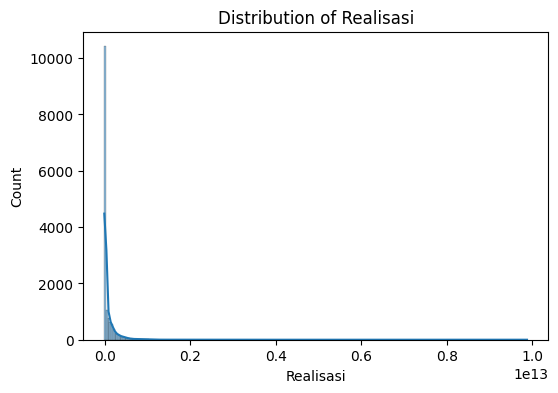

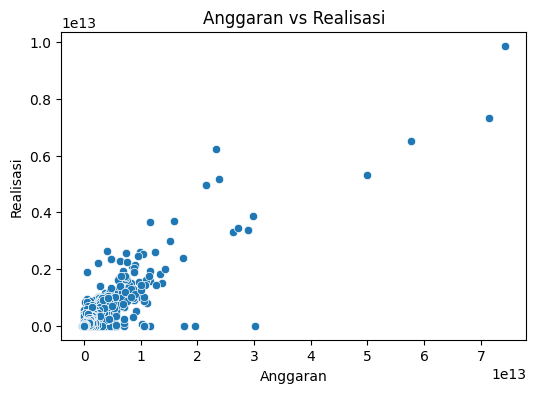

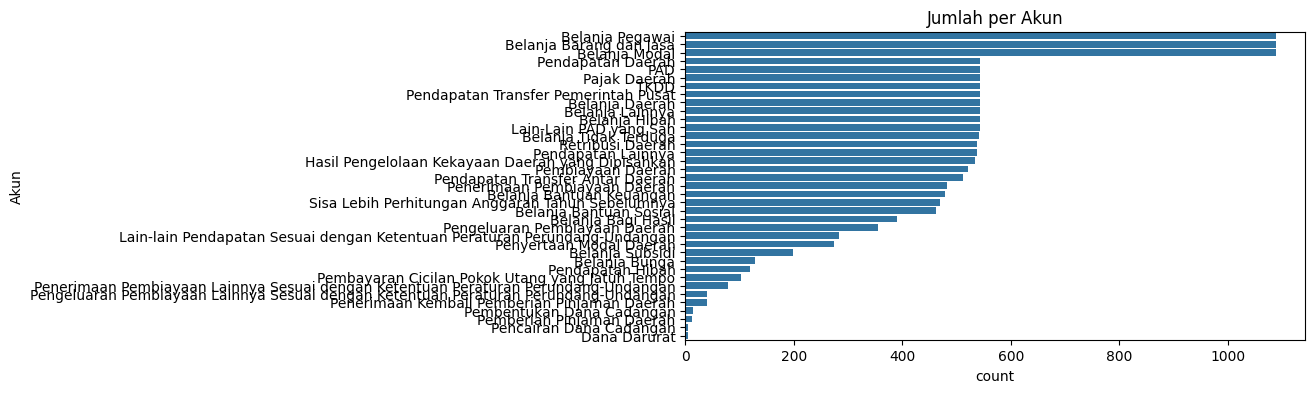

In [6]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

if {'Anggaran', 'Realisasi'}.issubset(dataset.columns):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=dataset, x='Anggaran', y='Realisasi')
    plt.title('Anggaran vs Realisasi')
    plt.show()

if 'Akun' in dataset.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=dataset, y='Akun', order=dataset['Akun'].value_counts().index)
    plt.title('Jumlah per Akun')
    plt.show()

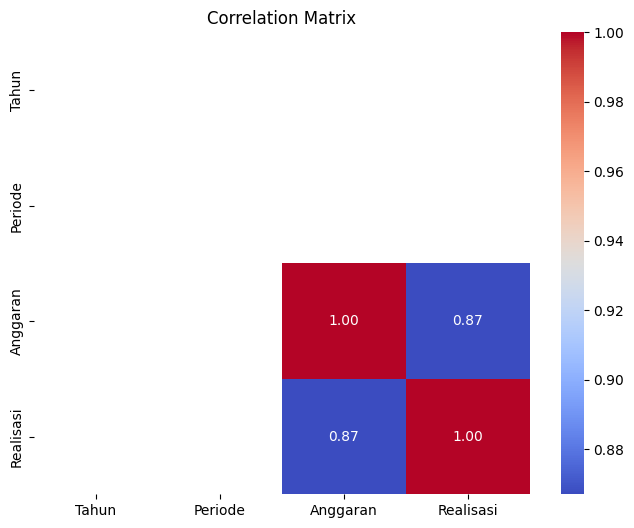

In [7]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = dataset[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
missing_values = dataset.isnull().sum()
missing_values[missing_values > 0]

Anggaran    176
dtype: int64

In [9]:
duplicate_count = dataset.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")
dataset[dataset.duplicated()].head()

Duplicate rows: 1632


,Tahun,Periode,Provinsi,Pemda,Akun,Anggaran,Realisasi,Persentase
13,2026,4,Provinsi Aceh,Kab. Pidie,Belanja Pegawai,8.275187e+11,2.233343e+11,26.99
15,2026,4,Provinsi Aceh,Kab. Pidie,Belanja Barang dan Jasa,4.881472e+11,3.845732e+10,7.88
17,2026,4,Provinsi Aceh,Kab. Pidie,Belanja Modal,1.838671e+11,1.710846e+09,0.93
42,2026,4,Provinsi Aceh,Kab. Simeulue,Belanja Pegawai,4.190351e+11,8.188413e+10,19.54
44,2026,4,Provinsi Aceh,Kab. Simeulue,Belanja Barang dan Jasa,2.046914e+11,1.532253e+10,7.49


In [10]:
target_column = 'Persentase'
X = dataset.drop(columns=[target_column])
y = dataset[target_column]

In [11]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

/tmp/ipykernel_7507/2450870045.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
 )

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [13]:
X_train_processed.shape, X_test_processed.shape

((10703, 623), (4588, 623))